<a href="https://colab.research.google.com/github/Saikumarmuddada/OBESITY-LEVEL-PREDICTION-USING-MACHINE-LEARNING/blob/main/modellling_part.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Using Machine Learning to Classify Obesity Levels Based on Lifestyle and Physical Condition**

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Load the dataset
file_path = '/content/ObesityDataSet_raw_and_data_sinthetic.csv'
df = pd.read_csv(file_path)

# Display the first 5 rows
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


# **Data Exploration and Visualization**
Before jumping into modeling, we need to check for missing values and understand the distribution of our target variable (NObeyesdad).

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

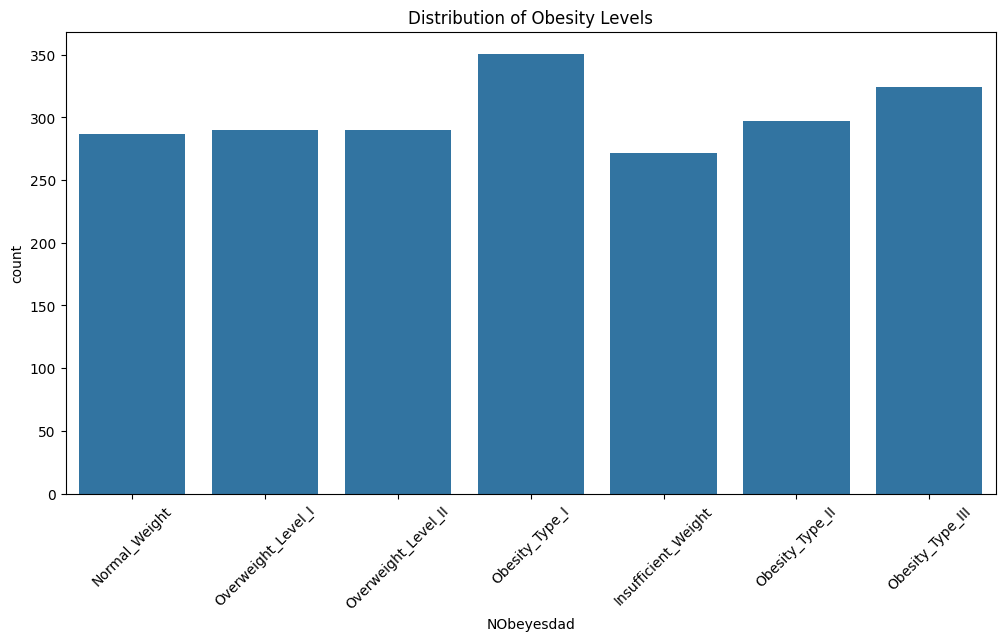

In [6]:
# Check for missing values and data types
print(df.info())

# Visualize the distribution of the target variable
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='NObeyesdad')
plt.xticks(rotation=45)
plt.title('Distribution of Obesity Levels')
plt.show()

## **Data Integrity & Cleaning**
This section ensures the reliability of our analysis by identifying and removing any inconsistent data points, such as duplicate records or missing entries.

In [7]:
# Check for missing values
print("--- Missing Values Check ---")
print(df.isnull().sum())

# Check for duplicate entries
duplicates_count = df.duplicated().sum()
print(f"\n--- Duplicate Entries Check ---")
print(f"Number of duplicate rows found: {duplicates_count}")

# Address duplicates: Remove duplicates to ensure each observation is unique
if duplicates_count > 0:
    df = df.drop_duplicates()
    print(f"Successfully removed {duplicates_count} duplicates.")
    print(f"New dataset shape: {df.shape}")
else:
    print("No duplicates found. Dataset integrity is intact.")

--- Missing Values Check ---
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

--- Duplicate Entries Check ---
Number of duplicate rows found: 24
Successfully removed 24 duplicates.
New dataset shape: (2087, 17)


## **Enhanced Distribution Analysis (Histograms)**
Unlike simple bar graphs, histograms allow us to see the continuous spread of numerical data. By adjusting the bin size, we can clearly identify "zero values" or ranges where no data exists, which is crucial for identifying sampling gaps.

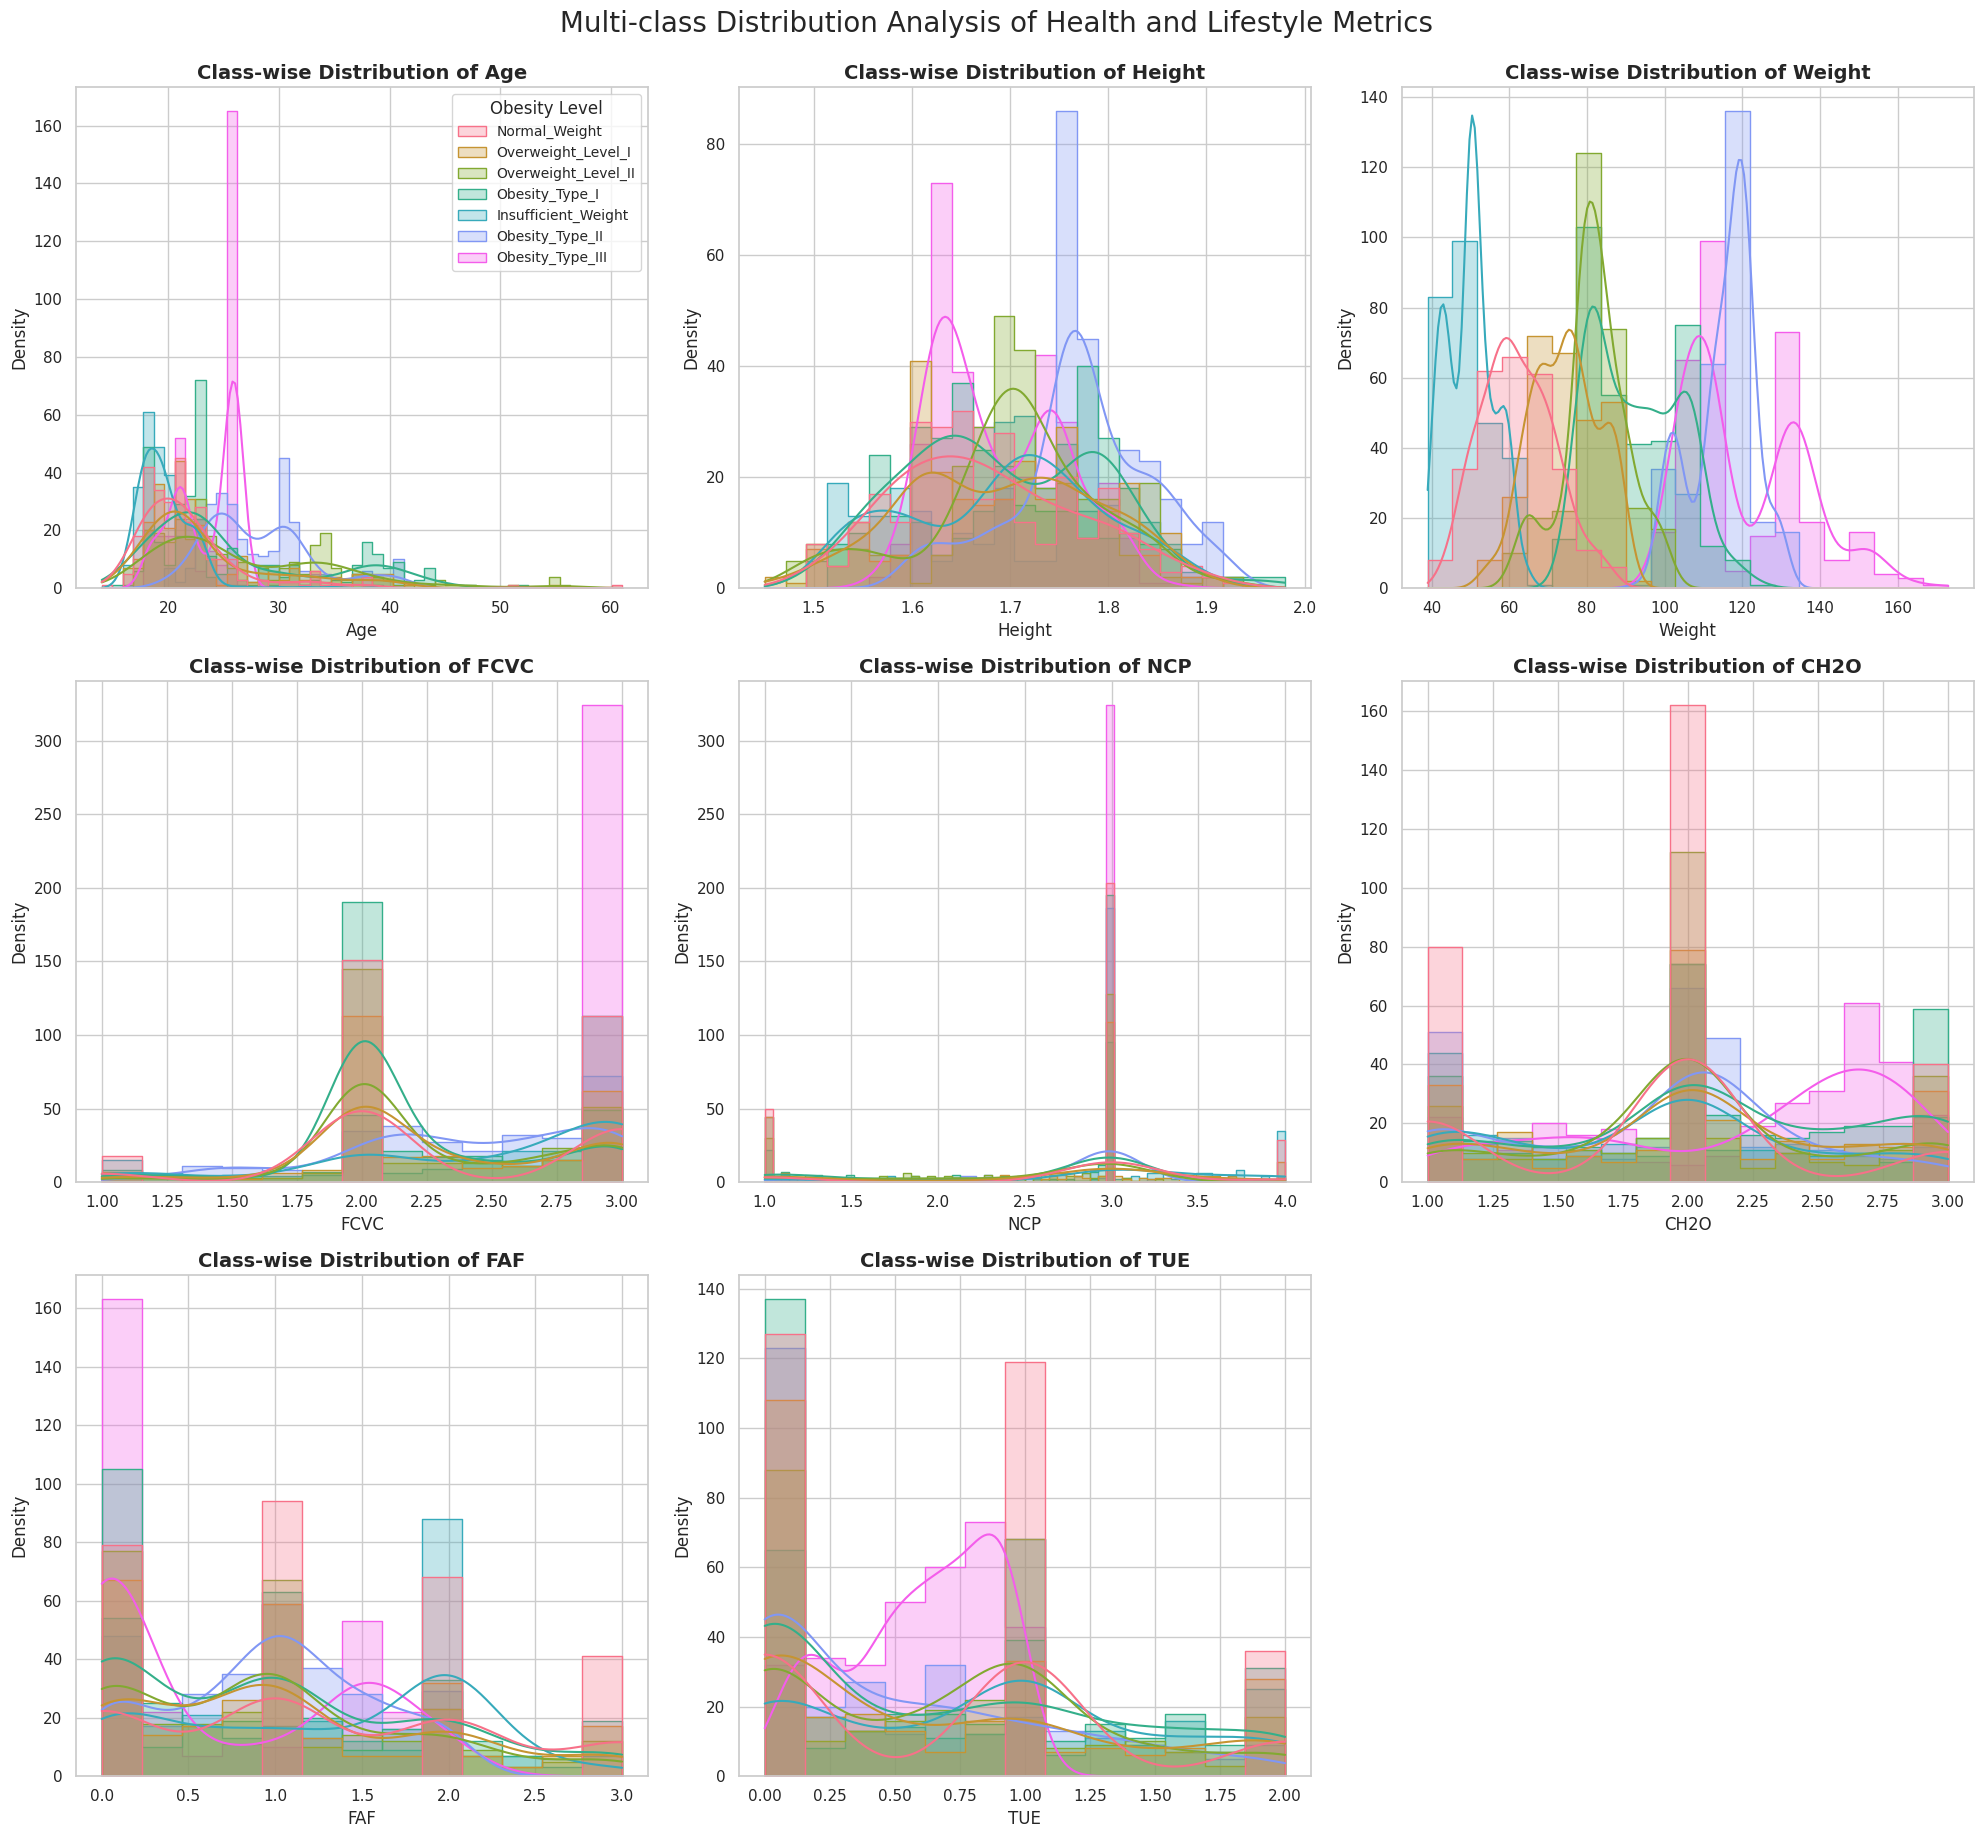

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define numerical columns for histogram analysis
num_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

# Set the theme and color palette
sns.set_theme(style="whitegrid")
# Using a distinct palette to differentiate the 7 obesity categories
palette = sns.color_palette("husl", 7)

# Create a grid of histograms broken down by Weight Category (NObeyesdad)
plt.figure(figsize=(20, 18))

for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i+1)

    # Use hue to separate by class
    # common_norm=False ensures the area of each class's KDE sums to 1,
    # making comparisons of distribution shape easier regardless of sample size.
    sns.histplot(
        data=df,
        x=col,
        hue='NObeyesdad',
        element="step",
        kde=True,
        palette=palette,
        common_norm=False,
        alpha=0.3
    )

    plt.title(f'Class-wise Distribution of {col}', fontsize=14, fontweight='bold')
    plt.xlabel(col)
    plt.ylabel('Density')

    # Relocate legend to avoid overlapping the data
    if i == 0:
        sns.move_legend(plt.gca(), "upper right", bbox_to_anchor=(1, 1), fontsize='small', title='Obesity Level')
    else:
        plt.gca().get_legend().remove()

plt.tight_layout()
plt.suptitle(' Multi-class Distribution Analysis of Health and Lifestyle Metrics', fontsize=20, y=1.02)
plt.show()

## **Lifestyle Breakdown by Weight Category**
To understand the relationship between habits and obesity levels, we analyze specific lifestyles (Physical Activity, Eating Habits, and Transportation) across the different weight categories.

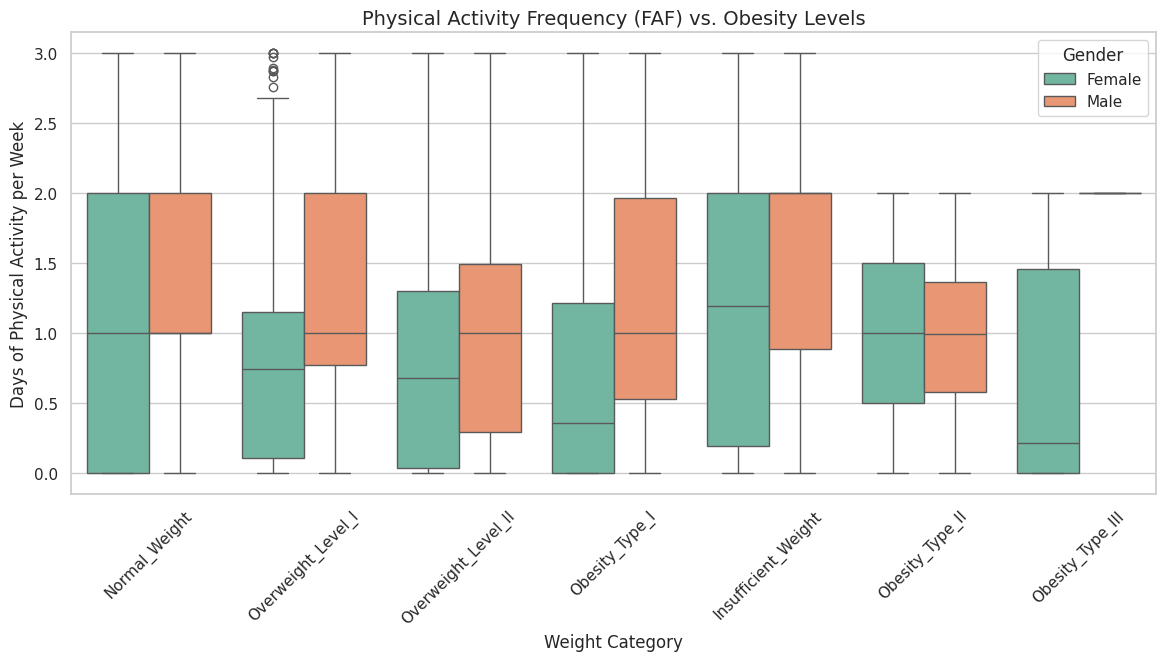

<Figure size 1400x600 with 0 Axes>

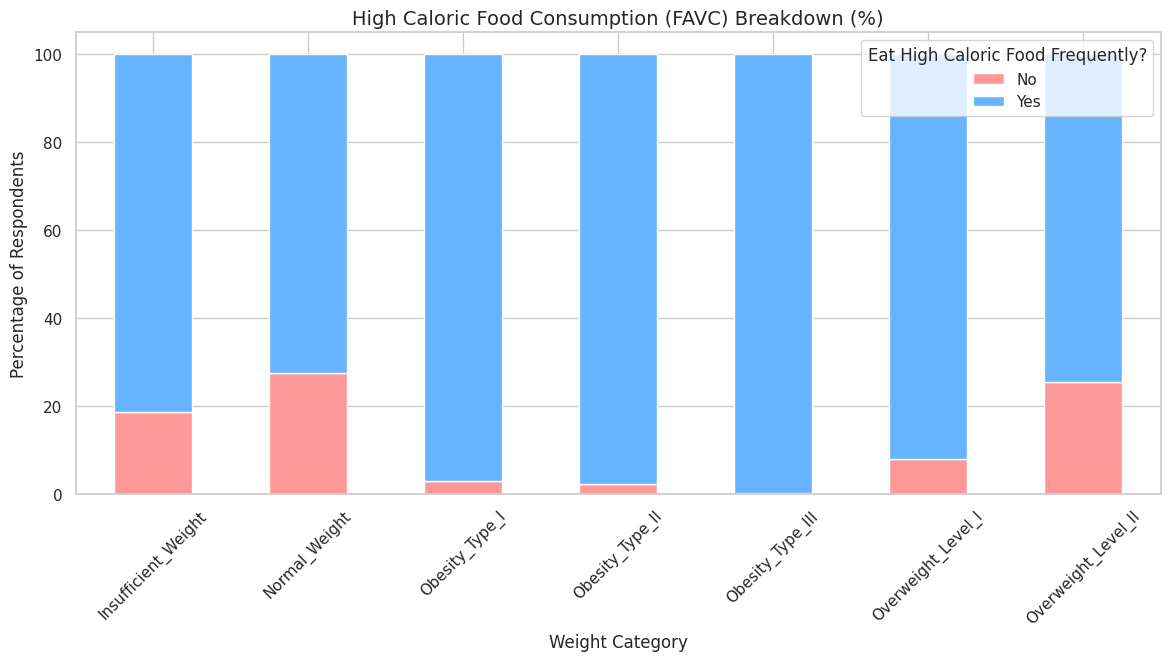

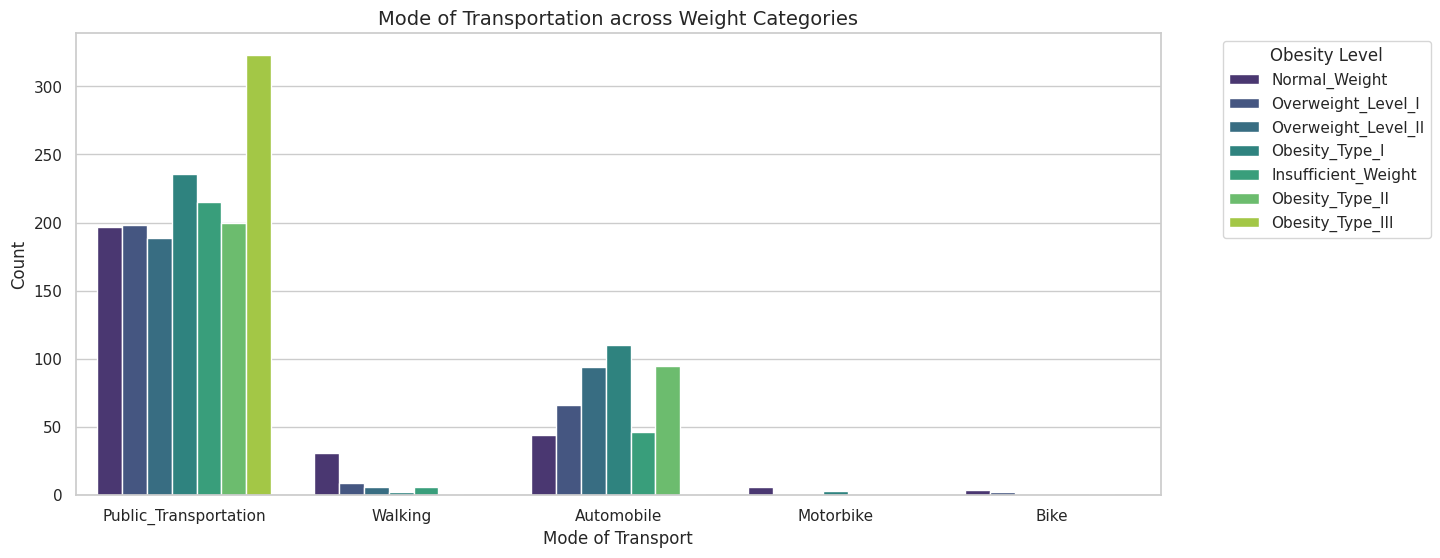

In [9]:
# 1. Physical Activity Frequency (FAF) across Obesity Levels
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='NObeyesdad', y='FAF', hue='Gender', palette='Set2')
plt.xticks(rotation=45)
plt.title('Physical Activity Frequency (FAF) vs. Obesity Levels', fontsize=14)
plt.xlabel('Weight Category')
plt.ylabel('Days of Physical Activity per Week')
plt.legend(title='Gender', loc='upper right')
plt.show()

# 2. Lifestyle Habits: High Caloric Food Consumption (FAVC) by Weight Category
plt.figure(figsize=(14, 6))
# Creating a cross-tabulation for a stacked bar look
lifestyle_cross = pd.crosstab(df['NObeyesdad'], df['FAVC'], normalize='index') * 100
lifestyle_cross.plot(kind='bar', stacked=True, figsize=(14, 6), color=['#ff9999','#66b3ff'])

plt.title('High Caloric Food Consumption (FAVC) Breakdown (%)', fontsize=14)
plt.xlabel('Weight Category')
plt.ylabel('Percentage of Respondents')
plt.xticks(rotation=45)
plt.legend(title='Eat High Caloric Food Frequently?', labels=['No', 'Yes'])
plt.show()

# 3. Transportation Choice and Obesity Levels
plt.figure(figsize=(14, 6))
sns.countplot(data=df, x='MTRANS', hue='NObeyesdad', palette='viridis')
plt.title('Mode of Transportation across Weight Categories', fontsize=14)
plt.xlabel('Mode of Transport')
plt.ylabel('Count')
plt.legend(title='Obesity Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# **Feature Engineering and Preprocessing**
The dataset contains several categorical columns (like Gender, Family History, etc.). We will use Label Encoding for the categorical variables and split the data into training and testing sets.

In [10]:
# Encoding categorical variables
le = LabelEncoder()
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Splitting features and target
X = df.drop('NObeyesdad', axis=1)
y = df['NObeyesdad']

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training shape: {X_train.shape}")
print(f"Testing shape: {X_test.shape}")

Training shape: (1669, 16)
Testing shape: (418, 16)


In [11]:
# Initialize the StandardScaler
scaler = StandardScaler()

# List of numerical columns to scale (excluding the target if it was encoded)
# In this dataset, most features are now numeric after LabelEncoding
numerical_features = X_train.columns

# Fit on training data and transform both sets
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test_scaled[numerical_features] = scaler.transform(X_test[numerical_features])

# Verify the scaling
print("Mean of scaled training data (should be ~0):", np.mean(X_train_scaled.iloc[:, 0]))
print("Std deviation of scaled training data (should be ~1):", np.std(X_train_scaled.iloc[:, 0]))

# Preview the scaled features
X_train_scaled.head()

Mean of scaled training data (should be ~0): 5.747349869839036e-17
Std deviation of scaled training data (should be ~1): 0.9999999999999976


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS
44,0.981595,-0.527480,1.147924,-0.274109,-2.171579,-2.749359,-2.697482,0.404840,2.501698,-0.139814,-0.013481,-0.224379,1.152734,-1.090305,1.429604,0.505940
691,0.981595,-0.996823,0.896895,-1.365851,-2.171579,0.363721,0.906960,0.404840,0.325912,-0.139814,-0.382363,-0.224379,0.067637,0.561045,-0.510241,0.505940
667,0.981595,-0.309000,1.786224,-0.986799,0.460495,0.363721,1.066005,0.748825,0.325912,-0.139814,0.373239,-0.224379,0.632537,-1.089719,-0.510241,-1.868232
170,0.981595,-0.371032,0.175861,-0.197429,-2.171579,0.363721,-0.815738,-2.209011,0.325912,-0.139814,-0.013481,-0.224379,1.152734,0.561045,-0.510241,0.505940
310,0.981595,-1.153270,0.931910,-1.155920,0.460495,0.363721,-0.815738,1.711766,-1.849875,-0.139814,-0.013481,-0.224379,1.152734,0.561045,1.429604,0.505940


# **Machine Learning Model**

## **Random Forest - Training and Comprehensive Evaluation**
This cell trains the Random Forest classifier, measures training/testing time, calculates overall and per-class metrics, and visualizes the results with a Confusion Matrix and ROC Curves.

=== Random Forest Performance Summary ===
Training Time: 0.4520s | Testing Time: 0.0295s
---------------------------------------------
Overall Accuracy:  0.9569
Weighted Precision: 0.9606
Weighted Recall:    0.9569
Weighted F1-Score:  0.9576
Macro F1-Score:     0.9560
---------------------------------------------

Per-Class Detailed Metrics:
              Class  Precision   Recall  F1-Score
Insufficient_Weight   0.982143 0.932203  0.956522
      Normal_Weight   0.842857 0.967213  0.900763
     Obesity_Type_I   1.000000 0.942857  0.970588
    Obesity_Type_II   1.000000 1.000000  1.000000
   Obesity_Type_III   1.000000 1.000000  1.000000
 Overweight_Level_I   0.980000 0.890909  0.933333
Overweight_Level_II   0.903846 0.959184  0.930693


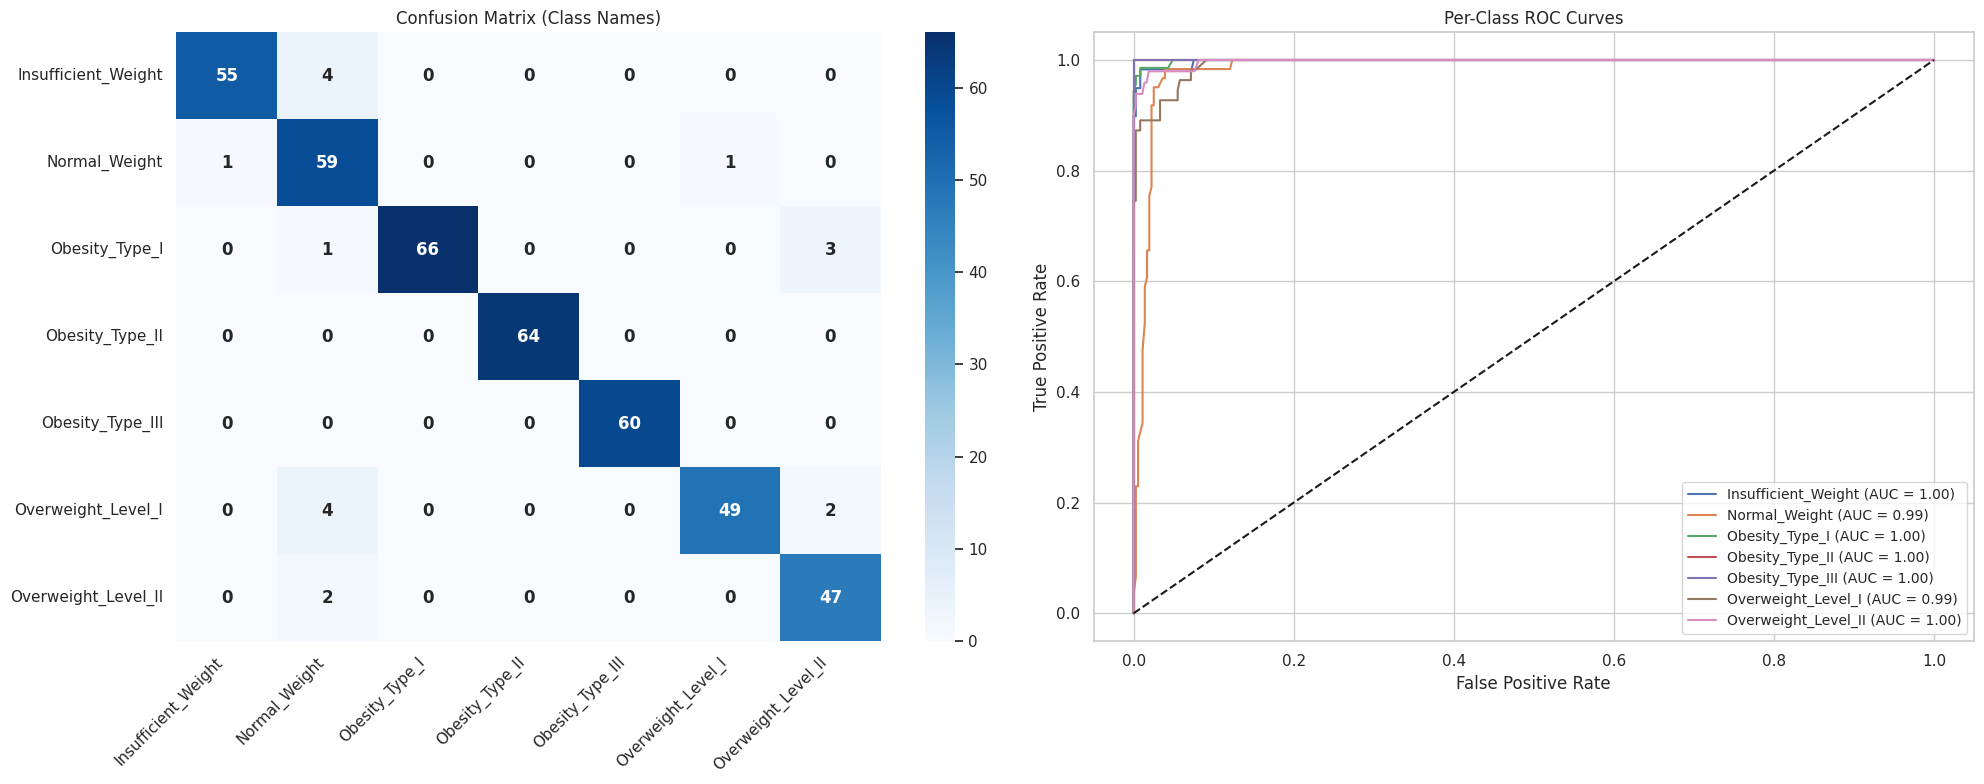

In [12]:
import time
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc,
                             precision_recall_fscore_support)
from sklearn.preprocessing import label_binarize

# 1. Training with Timing
start_train = time.time()
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
train_time = time.time() - start_train

# 2. Testing with Timing
start_test = time.time()
rf_preds = rf_model.predict(X_test_scaled)
rf_probs = rf_model.predict_proba(X_test_scaled)
test_time = time.time() - start_test

# 3. Overall Performance Metrics
accuracy = accuracy_score(y_test, rf_preds)
weighted_precision = precision_score(y_test, rf_preds, average='weighted')
weighted_recall = recall_score(y_test, rf_preds, average='weighted')
weighted_f1 = f1_score(y_test, rf_preds, average='weighted')
macro_f1 = f1_score(y_test, rf_preds, average='macro')

# 4. Printing Detailed Results
print(f"=== Random Forest Performance Summary ===")
print(f"Training Time: {train_time:.4f}s | Testing Time: {test_time:.4f}s")
print("-" * 45)
print(f"Overall Accuracy:  {accuracy:.4f}")
print(f"Weighted Precision: {weighted_precision:.4f}")
print(f"Weighted Recall:    {weighted_recall:.4f}")
print(f"Weighted F1-Score:  {weighted_f1:.4f}")
print(f"Macro F1-Score:     {macro_f1:.4f}")
print("-" * 45)

# Per-Class Metrics Table
class_names = le.classes_
p, r, f, _ = precision_recall_fscore_support(y_test, rf_preds, average=None)
metrics_df = pd.DataFrame({'Class': class_names, 'Precision': p, 'Recall': r, 'F1-Score': f})
print("\nPer-Class Detailed Metrics:")
print(metrics_df.to_string(index=False))

# 5. Visualizations
fig, ax = plt.subplots(1, 2, figsize=(20, 8))

# Confusion Matrix with BOLD annotations
cm = confusion_matrix(y_test, rf_preds)
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            ax=ax[0],
            xticklabels=class_names,
            yticklabels=class_names,
            annot_kws={'weight': 'bold', 'size': 12}) # <--- THIS BOLDS THE NUMBERS

ax[0].set_title('Confusion Matrix (Class Names)')
ax[0].set_xticklabels(class_names, rotation=45, ha='right')

# Per-Class ROC Curve
y_test_bin = label_binarize(y_test, classes=range(len(class_names)))
for i in range(len(class_names)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], rf_probs[:, i])
    ax[1].plot(fpr, tpr, label=f'{class_names[i]} (AUC = {auc(fpr, tpr):.2f})')

ax[1].plot([0, 1], [0, 1], 'k--')
ax[1].set_title('Per-Class ROC Curves')
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].legend(loc='lower right', fontsize='small')

plt.tight_layout()
plt.show()

## **Support Vector Machine (SVM) - Training and Evaluation**
This cell trains the SVM model with a linear kernel. SVM is particularly effective at finding the optimal boundary between different obesity categories.

=== SVM Performance Summary ===
Training Time: 0.3712s | Testing Time: 0.0207s
---------------------------------------------
Overall Accuracy:   0.9498
Weighted Precision: 0.9519
Weighted Recall:    0.9498
Weighted F1-Score:  0.9495
Macro F1-Score:     0.9479
---------------------------------------------

Per-Class Detailed Metrics:
              Class  Precision   Recall  F1-Score
Insufficient_Weight   0.892308 0.983051  0.935484
      Normal_Weight   0.962963 0.852459  0.904348
     Obesity_Type_I   1.000000 0.942857  0.970588
    Obesity_Type_II   0.955224 1.000000  0.977099
   Obesity_Type_III   1.000000 1.000000  1.000000
 Overweight_Level_I   0.942308 0.890909  0.915888
Overweight_Level_II   0.888889 0.979592  0.932039


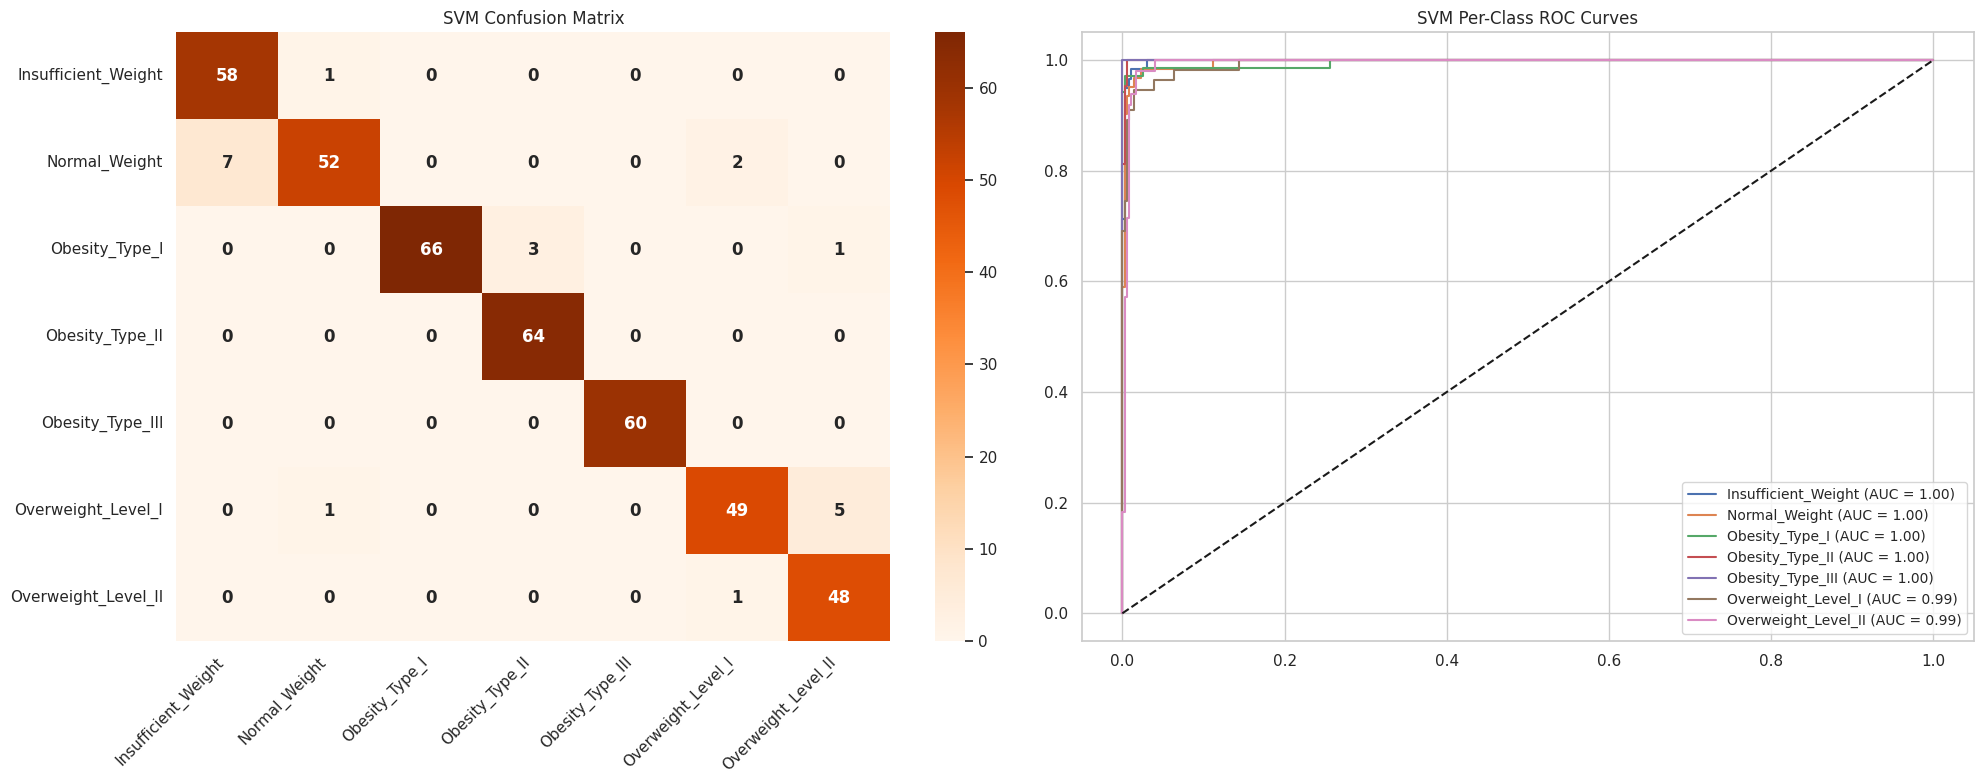

In [13]:
from sklearn.svm import SVC

# 1. Training with Timing
start_train = time.time()
# probability=True is required to plot the ROC curve later
svm_model = SVC(kernel='linear', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)
train_time = time.time() - start_train

# 2. Testing with Timing
start_test = time.time()
svm_preds = svm_model.predict(X_test_scaled)
svm_probs = svm_model.predict_proba(X_test_scaled)
test_time = time.time() - start_test

# 3. Overall Performance Metrics
accuracy = accuracy_score(y_test, svm_preds)
weighted_precision = precision_score(y_test, svm_preds, average='weighted')
weighted_recall = recall_score(y_test, svm_preds, average='weighted')
weighted_f1 = f1_score(y_test, svm_preds, average='weighted')
macro_f1 = f1_score(y_test, svm_preds, average='macro')

# 4. Printing Detailed Results
print(f"=== SVM Performance Summary ===")
print(f"Training Time: {train_time:.4f}s | Testing Time: {test_time:.4f}s")
print("-" * 45)
print(f"Overall Accuracy:   {accuracy:.4f}")
print(f"Weighted Precision: {weighted_precision:.4f}")
print(f"Weighted Recall:    {weighted_recall:.4f}")
print(f"Weighted F1-Score:  {weighted_f1:.4f}")
print(f"Macro F1-Score:     {macro_f1:.4f}")
print("-" * 45)

# Per-Class Metrics Table
p, r, f, _ = precision_recall_fscore_support(y_test, svm_preds, average=None)
metrics_df = pd.DataFrame({'Class': class_names, 'Precision': p, 'Recall': r, 'F1-Score': f})
print("\nPer-Class Detailed Metrics:")
print(metrics_df.to_string(index=False))

# 5. Visualizations
fig, ax = plt.subplots(1, 2, figsize=(20, 8))

# Confusion Matrix with BOLD annotations
cm = confusion_matrix(y_test, svm_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=ax[0],
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={'weight': 'bold', 'size': 12})
ax[0].set_title('SVM Confusion Matrix')
ax[0].set_xticklabels(class_names, rotation=45, ha='right')

# Per-Class ROC Curve
for i in range(len(class_names)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], svm_probs[:, i])
    ax[1].plot(fpr, tpr, label=f'{class_names[i]} (AUC = {auc(fpr, tpr):.2f})')

ax[1].plot([0, 1], [0, 1], 'k--')
ax[1].set_title('SVM Per-Class ROC Curves')
ax[1].legend(loc='lower right', fontsize='small')
plt.tight_layout()
plt.show()

## **Logistic Regression - Training and Evaluation**
This cell evaluate Logistic Regression. It is a linear model that is often very efficient in terms of training time while maintaining high accuracy on scaled datasets.

=== Logistic Regression Performance Summary ===
Training Time: 0.0728s | Testing Time: 0.0054s
---------------------------------------------
Overall Accuracy:   0.8636
Weighted Precision: 0.8663
Weighted Recall:    0.8636
Weighted F1-Score:  0.8612
Macro F1-Score:     0.8548
---------------------------------------------

Per-Class Detailed Metrics:
              Class  Precision   Recall  F1-Score
Insufficient_Weight   0.833333 0.932203  0.880000
      Normal_Weight   0.840909 0.606557  0.704762
     Obesity_Type_I   0.927536 0.914286  0.920863
    Obesity_Type_II   0.969697 1.000000  0.984615
   Obesity_Type_III   1.000000 1.000000  1.000000
 Overweight_Level_I   0.732143 0.745455  0.738739
Overweight_Level_II   0.701754 0.816327  0.754717


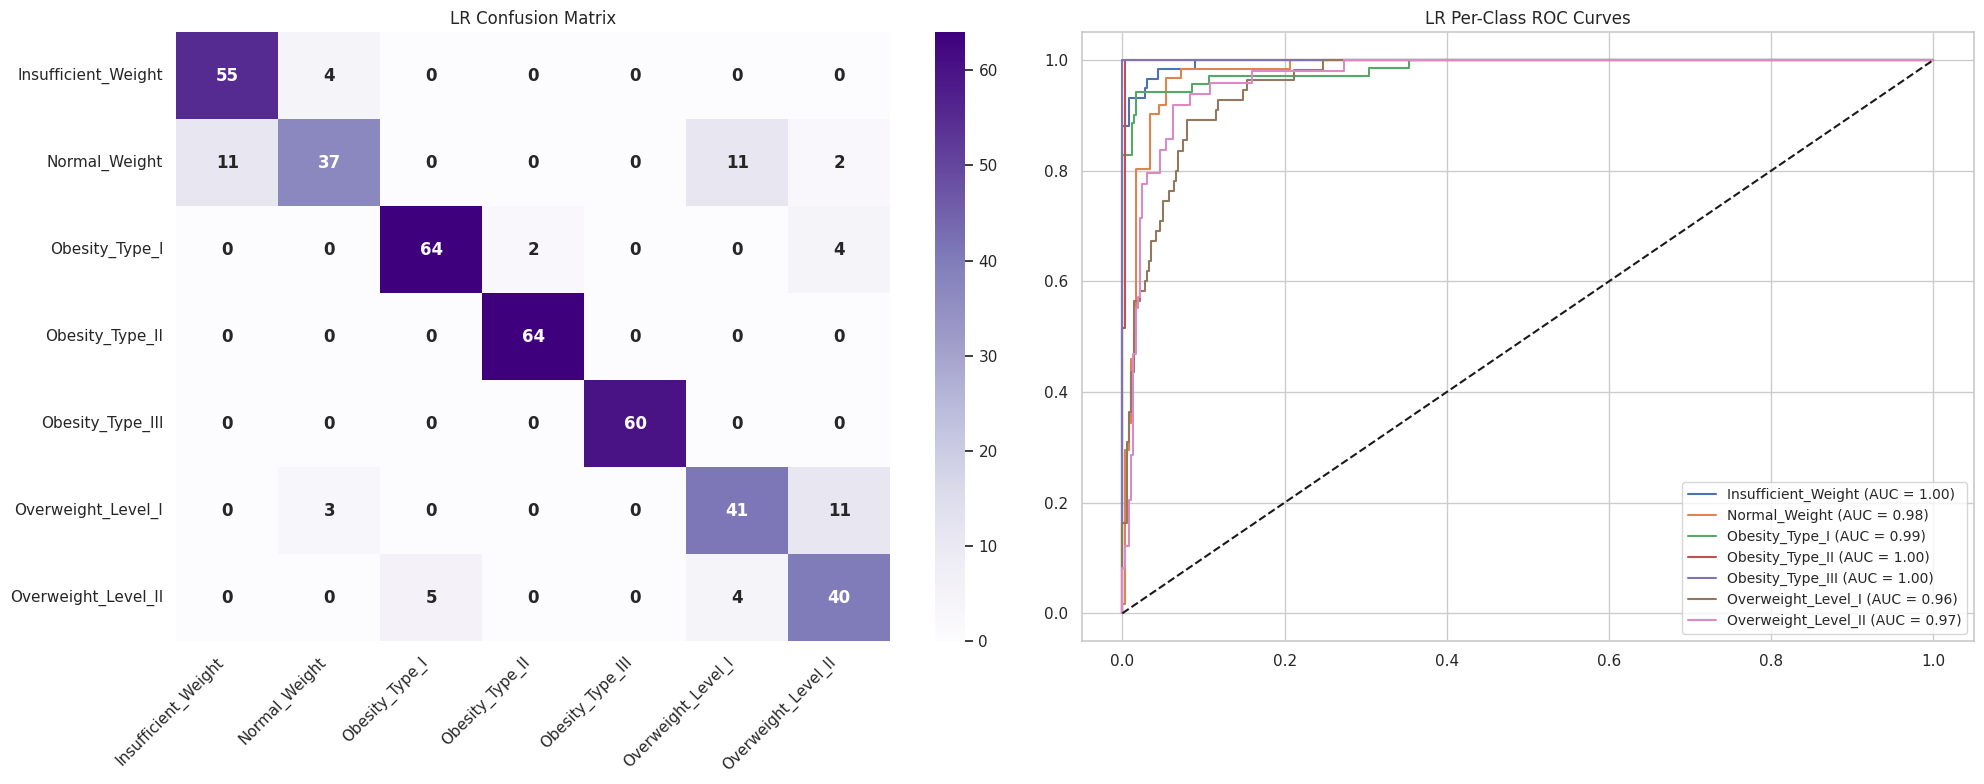

In [14]:
from sklearn.linear_model import LogisticRegression

# 1. Training with Timing
start_train = time.time()
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
train_time = time.time() - start_train

# 2. Testing with Timing
start_test = time.time()
lr_preds = lr_model.predict(X_test_scaled)
lr_probs = lr_model.predict_proba(X_test_scaled)
test_time = time.time() - start_test

# 3. Overall Performance Metrics
accuracy = accuracy_score(y_test, lr_preds)
weighted_precision = precision_score(y_test, lr_preds, average='weighted')
weighted_recall = recall_score(y_test, lr_preds, average='weighted')
weighted_f1 = f1_score(y_test, lr_preds, average='weighted')
macro_f1 = f1_score(y_test, lr_preds, average='macro')

# 4. Printing Detailed Results
print(f"=== Logistic Regression Performance Summary ===")
print(f"Training Time: {train_time:.4f}s | Testing Time: {test_time:.4f}s")
print("-" * 45)
print(f"Overall Accuracy:   {accuracy:.4f}")
print(f"Weighted Precision: {weighted_precision:.4f}")
print(f"Weighted Recall:    {weighted_recall:.4f}")
print(f"Weighted F1-Score:  {weighted_f1:.4f}")
print(f"Macro F1-Score:     {macro_f1:.4f}")
print("-" * 45)

# Per-Class Metrics Table
p, r, f, _ = precision_recall_fscore_support(y_test, lr_preds, average=None)
metrics_df = pd.DataFrame({'Class': class_names, 'Precision': p, 'Recall': r, 'F1-Score': f})
print("\nPer-Class Detailed Metrics:")
print(metrics_df.to_string(index=False))

# 5. Visualizations
fig, ax = plt.subplots(1, 2, figsize=(20, 8))

# Confusion Matrix with BOLD annotations
cm = confusion_matrix(y_test, lr_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=ax[0],
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={'weight': 'bold', 'size': 12})
ax[0].set_title('LR Confusion Matrix')
ax[0].set_xticklabels(class_names, rotation=45, ha='right')

# Per-Class ROC Curve
for i in range(len(class_names)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], lr_probs[:, i])
    ax[1].plot(fpr, tpr, label=f'{class_names[i]} (AUC = {auc(fpr, tpr):.2f})')

ax[1].plot([0, 1], [0, 1], 'k--')
ax[1].set_title('LR Per-Class ROC Curves')
ax[1].legend(loc='lower right', fontsize='small')
plt.tight_layout()
plt.show()